Install & Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


Load Dataset


In [2]:
# Load the California Housing dataset
# This is built into sklearn so no download is needed!
# It has data about houses in California

from sklearn.datasets import fetch_california_housing

print("Loading California Housing dataset...")
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target (house price in $100,000 units)
df['Price'] = housing.target

print("Dataset loaded!")
print("Rows:", len(df))
print("Columns:", list(df.columns))
print("")
print("Column Descriptions:")
print("MedInc     - Median income in block group")
print("HouseAge   - Median house age in block group")
print("AveRooms   - Average number of rooms")
print("AveBedrms  - Average number of bedrooms")
print("Population - Block group population")
print("AveOccup   - Average household size")
print("Latitude   - Block group latitude")
print("Longitude  - Block group longitude")
print("Price      - Target: Median house value ($100,000 units)")

Loading California Housing dataset...
Dataset loaded!
Rows: 20640
Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']

Column Descriptions:
MedInc     - Median income in block group
HouseAge   - Median house age in block group
AveRooms   - Average number of rooms
AveBedrms  - Average number of bedrooms
Population - Block group population
AveOccup   - Average household size
Latitude   - Block group latitude
Longitude  - Block group longitude
Price      - Target: Median house value ($100,000 units)


Explore the Data

In [3]:
# Check basic information about the dataset

print("First 5 rows:")
print(df.head())

print("")
print("Statistics:")
print(df.describe().round(2))

print("")
print("Missing values:", df.isnull().sum().sum())

print("")
print("Average house price: $" + str(round(df['Price'].mean() * 100000, 0)))
print("Cheapest house:     $" + str(round(df['Price'].min() * 100000, 0)))
print("Most expensive:     $" + str(round(df['Price'].max() * 100000, 0)))

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  

Statistics:
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.0

Visualize the Data

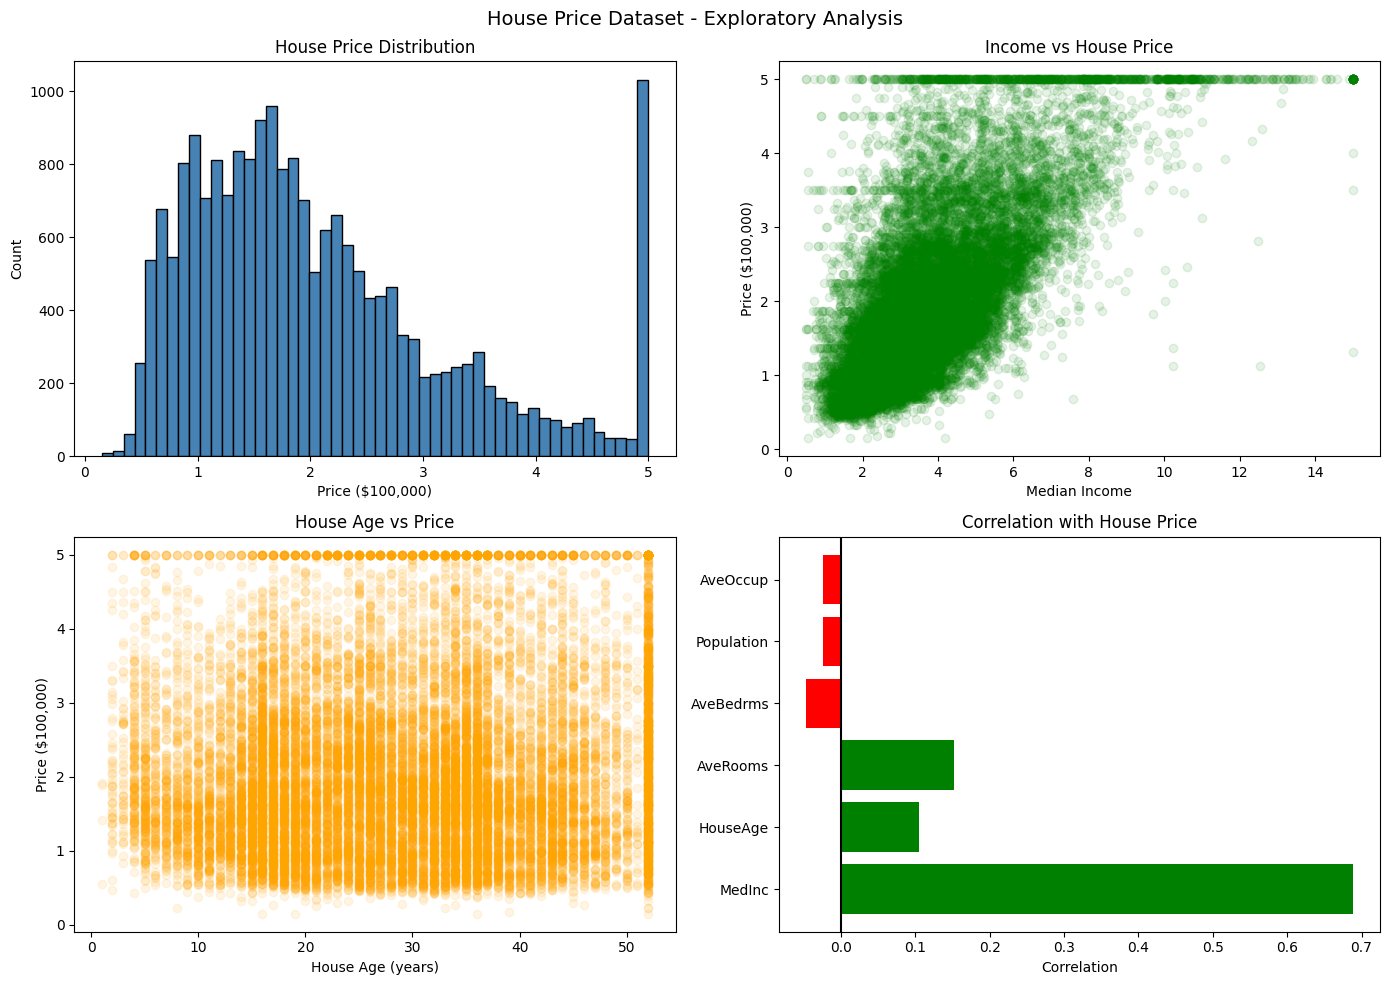

EDA charts saved!


In [4]:
# Create 4 charts to understand the data

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Chart 1: Distribution of house prices
axes[0][0].hist(df['Price'], bins=50, color='steelblue', edgecolor='black')
axes[0][0].set_title('House Price Distribution')
axes[0][0].set_xlabel('Price ($100,000)')
axes[0][0].set_ylabel('Count')

# Chart 2: Income vs Price scatter plot
axes[0][1].scatter(df['MedInc'], df['Price'],
                   alpha=0.1, color='green')
axes[0][1].set_title('Income vs House Price')
axes[0][1].set_xlabel('Median Income')
axes[0][1].set_ylabel('Price ($100,000)')

# Chart 3: House Age vs Price
axes[1][0].scatter(df['HouseAge'], df['Price'],
                   alpha=0.1, color='orange')
axes[1][0].set_title('House Age vs Price')
axes[1][0].set_xlabel('House Age (years)')
axes[1][0].set_ylabel('Price ($100,000)')

# Chart 4: Correlation with price
number_cols = ['MedInc', 'HouseAge', 'AveRooms',
               'AveBedrms', 'Population', 'AveOccup']
correlations = []
for col in number_cols:
    corr = df[col].corr(df['Price'])
    correlations.append(corr)

colors = ['green' if c > 0 else 'red' for c in correlations]
axes[1][1].barh(number_cols, correlations, color=colors)
axes[1][1].axvline(0, color='black')
axes[1][1].set_title('Correlation with House Price')
axes[1][1].set_xlabel('Correlation')

plt.suptitle('House Price Dataset - Exploratory Analysis', fontsize=14)
plt.tight_layout()
plt.savefig('task6_eda.png')
plt.show()

print("EDA charts saved!")

Prepare Data for Training

In [5]:
# Separate features from target

# X = features (inputs to model)
X = df.drop('Price', axis=1)

# y = target (what we predict)
y = df['Price']

# Split into 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Scale features
# StandardScaler makes all features have same range
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Data ready!")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Data ready!
Training samples: 16512
Testing samples: 4128


Train Model

In [6]:
# Model 1: Linear Regression (simple, fast)
print("Training Linear Regression...")
linear_model = LinearRegression()
linear_model.fit(X_train_scaled, y_train)
linear_predictions = linear_model.predict(X_test_scaled)
print("Done!")

# Model 2: Gradient Boosting (powerful, slower)
print("Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=100,    # 100 trees
    max_depth=4,         # each tree max 4 levels deep
    learning_rate=0.1,   # how much each tree contributes
    random_state=42
)
gb_model.fit(X_train_scaled, y_train)
gb_predictions = gb_model.predict(X_test_scaled)
print("Done!")

# Evaluate both models
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print("")
    print("Model:", name)
    print("MAE  (avg error in $100k):", round(mae, 4))
    print("RMSE (large error penalty):", round(rmse, 4))
    print("In dollars - avg error: $" + str(round(mae * 100000, 0)))

evaluate("Linear Regression", y_test, linear_predictions)
evaluate("Gradient Boosting", y_test, gb_predictions)

Training Linear Regression...
Done!
Training Gradient Boosting...
Done!

Model: Linear Regression
MAE  (avg error in $100k): 0.5332
RMSE (large error penalty): 0.7456
In dollars - avg error: $53320.0

Model: Gradient Boosting
MAE  (avg error in $100k): 0.3449
RMSE (large error penalty): 0.5094
In dollars - avg error: $34486.0


Plot Actual vs Predicted

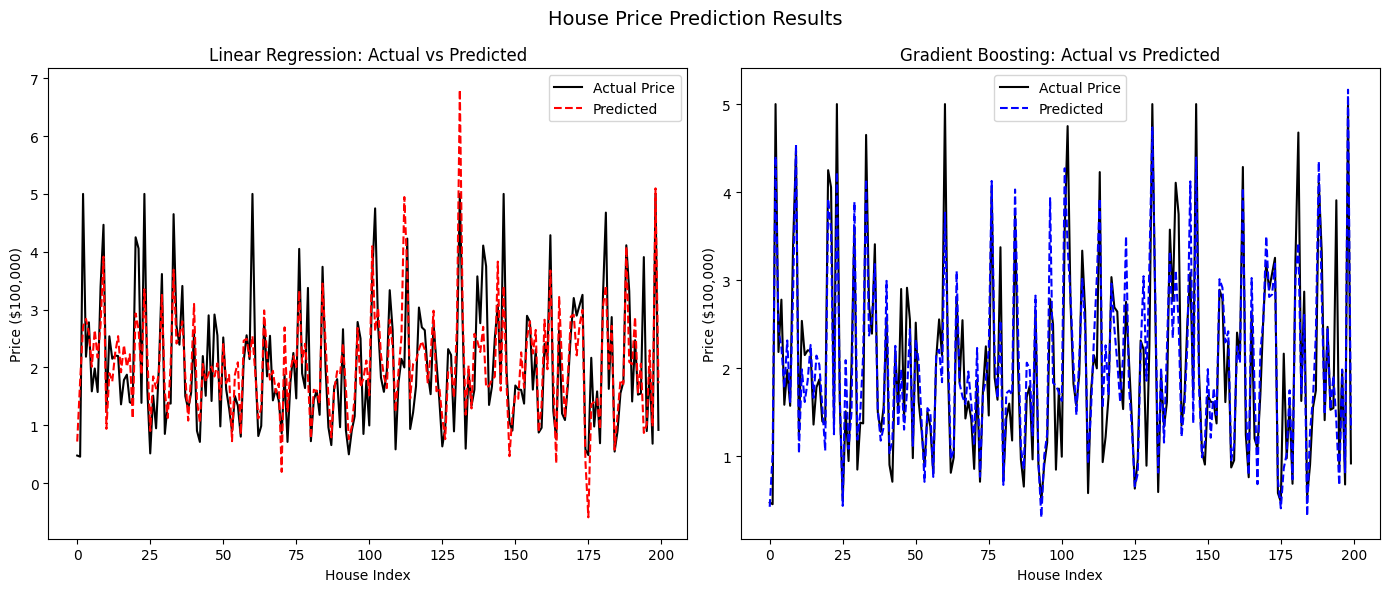

Prediction plots saved!


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Show only first 200 test samples for clarity
n = 200
x_axis = range(n)

# Linear Regression plot
axes[0].plot(x_axis, y_test.values[:n],
             color='black', label='Actual Price', linewidth=1.5)
axes[0].plot(x_axis, linear_predictions[:n],
             color='red', label='Predicted', linestyle='--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('House Index')
axes[0].set_ylabel('Price ($100,000)')
axes[0].legend()

# Gradient Boosting plot
axes[1].plot(x_axis, y_test.values[:n],
             color='black', label='Actual Price', linewidth=1.5)
axes[1].plot(x_axis, gb_predictions[:n],
             color='blue', label='Predicted', linestyle='--')
axes[1].set_title('Gradient Boosting: Actual vs Predicted')
axes[1].set_xlabel('House Index')
axes[1].set_ylabel('Price ($100,000)')
axes[1].legend()

plt.suptitle('House Price Prediction Results', fontsize=14)
plt.tight_layout()
plt.savefig('task6_predictions.png')
plt.show()

print("Prediction plots saved!")

Scatter Plot (Perfect Prediction Line)

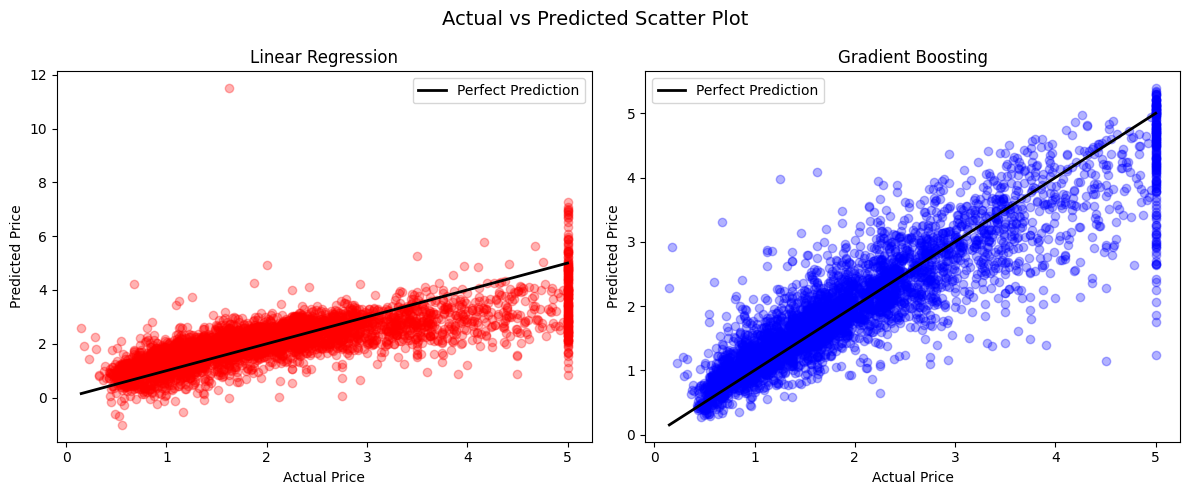

Scatter plots saved!

How to read this chart:
- Dots close to the black line = good predictions
- Dots far from line = bad predictions


In [8]:
# Another way to check model quality
# If predictions = actual, all dots should be on the diagonal line

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear Regression scatter
axes[0].scatter(y_test, linear_predictions, alpha=0.3, color='red')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='black', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Linear Regression')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].legend()

# Gradient Boosting scatter
axes[1].scatter(y_test, gb_predictions, alpha=0.3, color='blue')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='black', linewidth=2, label='Perfect Prediction')
axes[1].set_title('Gradient Boosting')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].legend()

plt.suptitle('Actual vs Predicted Scatter Plot', fontsize=14)
plt.tight_layout()
plt.savefig('task6_scatter.png')
plt.show()

print("Scatter plots saved!")
print("")
print("How to read this chart:")
print("- Dots close to the black line = good predictions")
print("- Dots far from line = bad predictions")